In [1]:
import torch
from torch.autograd import grad
from scipy.io import savemat, loadmat


import pandas as pd
import seaborn as sns
import math
import scipy.io as sio
import matplotlib.pyplot as plt
from pinnutils import *
from chebyshev_utils import *
from GEOMLOSS import samples_loss
from tqdm import tqdm_notebook as tqdm
import os
from genesets import genesets
from genesets_exvivo import genesets_exvivo

os.environ["PYTORCH_CUDA_ALLOC_CONF"] = "max_split_size_mb:32768"

import scvelo as scv
import scanpy as sc
import anndata as ad

from TrajectoryNet.parse import parser
import random

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(device)

import matplotlib as mpl
mpl.rcParams.update({# Use mathtext, not LaTeX
                            'text.usetex': False,
                            # Use the Computer modern font
                            'font.family': 'serif',
                            'font.serif': 'cmr10',
                            'mathtext.fontset': 'cm',
                            # Use ASCII minus
                            'axes.unicode_minus': False,
                            })

2026-02-11 17:09:57.385460: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1770847797.399265 1926893 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1770847797.404190 1926893 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


cuda


In [116]:
def load_data(path,nsamples,genes,time_str,cell_type_str):
    Ndim = len(genes);
    args = parser.parse_args(args=[])
    args.dataset = path
    adata = sc.read_h5ad(args.dataset)

    unique_times = adata.obs[str(time_str)].unique()
    nsnaps = len(unique_times); 
    samples = np.zeros((len(unique_times),nsamples,Ndim+1))

    cell_type_categories = list(adata.obs[str(cell_type_str)].cat.categories)
    cell_type_to_int = {ct: i for i, ct in enumerate(cell_type_categories)}
    ind_array = np.zeros((nsnaps, nsamples), dtype=int)

    print(cell_type_categories, cell_type_to_int)

    for k in range(0,len(unique_times)):
        time_point = unique_times[k] # Replace with actual time (e.g., "10h" or 10)
        cells_at_time = adata[adata.obs[str(time_str)] == time_point]
        cell_names = cells_at_time.obs_names.tolist()
        selected = np.arange(0,nsamples)

        cell_types_k = cells_at_time.obs[str(cell_type_str)].iloc[selected].values
        ind_array[k, :] = [cell_type_to_int[ct] for ct in cell_types_k]
    
        expression_t0 = cells_at_time[:, genes].X
        expression_t0_numpy = expression_t0.toarray() if hasattr(expression_t0, "toarray") else np.array(expression_t0)
        print(" shape ", k, " : ", expression_t0_numpy.shape)
        
        samples[k,:,0:Ndim] = expression_t0_numpy[selected,:]
        samples[k,:,Ndim]   = k

    return samples, unique_times, ind_array, adata.obs[str(cell_type_str)]

geneset_num = 4;
genes = genesets_exvivo[geneset_num]
print(" genes used ", genes)

nsamples = 5_000; 
#path = '/mnt/ceph/users/smaddu/HSC_real/data_cleaned_hsc.h5ad'
#path = '/mnt/home/vchardes/ceph/datasets/exvivo_HSC/kaggle_multiome_RNA.h5ad'
path =  '/mnt/home/vchardes/ceph/datasets/HSC_data/10XChromiumV3_10.1038_s41467-021-27159-x_10.5281_zenodo.5291737_exvivo.h5ad'
samples, tp, ind_array, cell_type = load_data(path,nsamples,genes,"day","cell_type")
Ndim = len(genes);
Dist = samples[:,:,0:Ndim]
print(" samples shape ", samples.shape, ind_array.shape)
print(cell_type)

 genes used  ['fli1', 'klf1', 'gata1', 'gata2', 'gfi1b', 'zbtb7a', 'runx1', 'tal1', 'jun', 'spi1', 'zfpm1', 'lmo2', 'etv6', 'erg', 'mef2c', 'cebpa', 'nfe2', 'myc', 'stat3', 'nanog', 'meis1']
['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1', 'Mk2'] {'Ery1': 0, 'Ery2': 1, 'HSPC': 2, 'MPP1': 3, 'MPP2': 4, 'Mk1': 5, 'Mk2': 6}
 shape  0  :  (6203, 21)
 shape  1  :  (9197, 21)
 shape  2  :  (9789, 21)
 shape  3  :  (7739, 21)
 shape  4  :  (10387, 21)
 shape  5  :  (10188, 21)
 samples shape  (6, 5000, 22) (6, 5000)
ED00:AAACTTGACGTACAx      HSPC
ED00:AAATGTTGTACGACx      HSPC
ED00:AAACCGTGTGGTACx      HSPC
ED00:AAATTGACTGTGGTx      HSPC
ED00:AACAATACAATGCCx      HSPC
                          ... 
MD11:TTTGTCAGTGTTCTTTx     Mk1
MD11:TTTGTCACAGAAGCACx     Mk1
MD11:TTTGTCAAGAAGGTGAx     Mk1
MD11:TTTGCGCGTAAACACAx     Mk1
MD11:TTTGGTTAGTCTTGCAx     Mk2
Name: cell_type, Length: 53503, dtype: category
Categories (7, object): ['Ery1', 'Ery2', 'HSPC', 'MPP1', 'MPP2', 'Mk1', 'Mk2']


### Spectral norm has heavy inductive bias, but more stable in generating samples
### Without spectral norm, the neur

In [128]:
spectral_flag = True;

if(spectral_flag):
    scoreNet = torch.load('/mnt/ceph/users/smaddu/stochastic_inference/score_newset_spectral_exvivo_HSPC_general_N6000_Ndim'+str(Ndim)+'_Np90_seed0_set'+str(geneset_num)+'.pth',weights_only=False)
else:
    scoreNet = torch.load('/mnt/ceph/users/smaddu/stochastic_inference/score_newset_exvivo_HSPC_general_N6000_Ndim'+str(Ndim)+'_Np90_seed0_set'+str(geneset_num)+'.pth',weights_only=False)
scoreNet = scoreNet.eval()

In [129]:
scoreNet

SpectralNormDNN(
  (net): Sequential(
    (0): Linear(in_features=23, out_features=90, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=90, out_features=90, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=90, out_features=90, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=90, out_features=90, bias=True)
    (7): ELU(alpha=1.0)
    (8): Linear(in_features=90, out_features=90, bias=True)
    (9): ELU(alpha=1.0)
    (10): Linear(in_features=90, out_features=21, bias=True)
  )
)

 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 final mean  tensor([ 0.8947,  0.8333,  1.1932,  0.6550,  0.9089,  0.2473,  1.9849,  0.2760,
         0.2131,  0.0820,  0.2065,  0.6452,  1.0182,  0.3543,  0.9806,  0.0424,
         0.5585,  1.5802,  0.4254, -0.0020,  0.6362], device='cuda:0')
 divergence  tensor(0.9389, device='cuda:0')
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 final mean  tensor([ 0.9503,  0.8863,  1.2831,  0.6388,  0.9728,  0.2303,  1.8974,  0.3112,
         0.1526,  0.0617,  0.2330,  0.6849,  0.9750,  0.3011,  1.1200,  0.0304,
         0.6039,  1.4800,  0.4513, -0.0155,  0.6763], device='cuda:0')
 divergence  tensor(0.8793, device='cuda:0')
 sol shape  torch.Size([5000, 23])
 sol shape  torch.Size([5000, 23])
 s

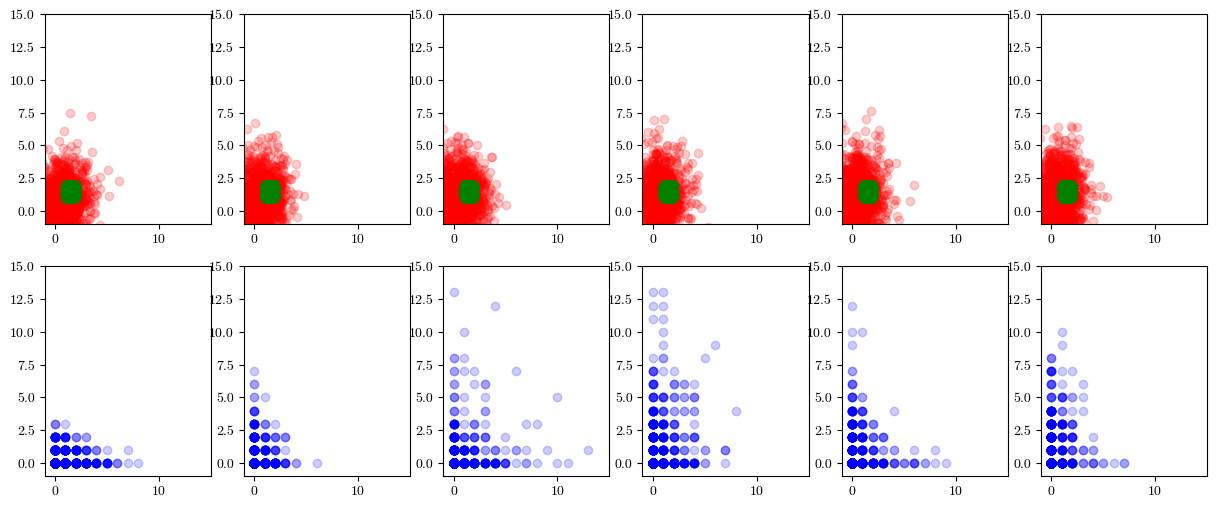

In [130]:
def generate_data_DSM(eps,maxiter,infNet,Nsamples,init_,time_,L):
    eps = 1e-4;
    sol = torch.tensor(init_,dtype=torch.float32).to(device)
    sol[:,Ndim+1] = time_
    sigma = geometric_sequence(L);
    for k in range(0,L):
        alpha = eps*((sigma[k]**2)/(sigma[L-1]**2))
        sol[:,Ndim] = sigma[k]
        print(" sol shape ", sol.shape)
        for t in range(0,maxiter):
            z = torch.normal(0, 1, size=(Nsamples, Ndim)).to(device)
            guru = infNet(sol) 
            sol[:,0:Ndim] = sol[:,0:Ndim] + 0.5*alpha*guru + np.sqrt(alpha)*z
    print(" final mean ",torch.mean(sol,axis=0)[0:Ndim])       
    sol = sol.cpu().data.numpy().reshape(Nsamples,Ndim+2)
    return sol

indx = 3; indy = 0;
nsnaps = Dist.shape[0]; nsamples = Dist.shape[1]; L = 5;
loss = samples_loss.SamplesLoss("energy")
eps = 5e-3; maxiter = 250; lim_ = 15; res = 4;
for tinf in range(0,nsnaps):
    with torch.no_grad():
        infNet = scoreNet.eval()
        init_  = np.random.uniform(1.0,2.0,(nsamples,Ndim+2))  #
        #init_[:,0:Ndim] = Dist[tinf,:,0:Ndim]
        sol = generate_data_DSM(eps,maxiter,infNet,nsamples,init_,tp[tinf],L);
        divergence = loss(torch.tensor(sol[0:5000,0:Ndim],dtype=torch.float32,device=device),torch.tensor(Dist[tinf,0:5000,0:Ndim],dtype=torch.float32,device=device))
        print(" divergence ", divergence)

    #print(sol[:,0:Ndim].shape, torch.tensor(Dist[tinf,:,0:Ndim],dtype=torch.float32,device=device).shape)
    plt.subplot(2,nsnaps,tinf+1)
    plt.scatter(sol[::res,indx],sol[::res,indy],color='red',alpha=0.2)
    plt.scatter(init_[::res,indx],init_[::res,indy],color='green')
    plt.xlim(-1,lim_); plt.ylim(-1,lim_); plt.xlim(-1,lim_); plt.ylim(-1,lim_)
    #plt.xlim(0,4); plt.ylim(0,4)
    #plt.scatter(init_[:,0],init_[:,1],color='green',alpha=0.2)
    #plt.scatter(Dist[tinf,:,3], Dist[tinf,:,1],color='blue',alpha=0.2)
    plt.subplot(2,nsnaps,nsnaps+tinf+1)
    plt.scatter(Dist[tinf,::res,indx],Dist[tinf,::res,indy],color='blue',alpha=0.2)
    plt.xlim(-1,lim_); plt.ylim(-1,lim_); plt.xlim(-1,lim_); plt.ylim(-1,lim_)
plt.gcf().set_size_inches(15,6)